# Cargar datos

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("reviews_by_course.csv")

# Visualización inicial

In [3]:
df.head()

,CourseId,Review,Label
0,2-speed-it,BOring,1
1,2-speed-it,Bravo !,5
2,2-speed-it,Very goo,5
3,2-speed-it,"Great course - I recommend it for all, especia...",5
4,2-speed-it,One of the most useful course on IT Management!,5


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 140320 entries, 0 to 140319
Data columns (total 3 columns):
 #   Column    Non-Null Count   Dtype 
---  ------    --------------   ----- 
 0   CourseId  140320 non-null  object
 1   Review    140317 non-null  object
 2   Label     140320 non-null  int64 
dtypes: int64(1), object(2)
memory usage: 3.2+ MB


# Limpieza básica

In [5]:
df.isnull().sum()

,0
CourseId,0
Review,3
Label,0


In [6]:
df.dropna(subset=["Review"], inplace=True)
df.drop_duplicates(inplace=True)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 137301 entries, 0 to 140319
Data columns (total 3 columns):
 #   Column    Non-Null Count   Dtype 
---  ------    --------------   ----- 
 0   CourseId  137301 non-null  object
 1   Review    137301 non-null  object
 2   Label     137301 non-null  int64 
dtypes: int64(1), object(2)
memory usage: 4.2+ MB


# Detectar idioma

In [8]:
!pip install langdetect

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 7.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for langdetect: filename=langdetect-1.0.9-py3-none-any.whl size=993223 sha256=28de58c81fd7d9657d93f98df0fdf33ff263d184087c6c53dd7041c495d02e37
  Stored in directory: /root/.cache/pip/wheels/c1/67/88/e844b5b022812e15a52e4eaa38a1e709e99f06f6639d7e3ba7
Successfully built langdetect


In [9]:
from langdetect import detect, DetectorFactory
from tqdm.auto import tqdm
tqdm.pandas()
DetectorFactory.seed = 42

In [10]:
def detectar_idioma(text):
    try:
        return detect(str(text))
    except:
        return "unknown"

In [11]:
df["language"] = df["Review"].progress_apply(detectar_idioma)

  0%|          | 0/137301 [00:00<?, ?it/s]

In [12]:
df["language"].value_counts().head(10)

,count
language,
en,105777
es,12162
fr,3470
zh-cn,2328
pt,2158
ro,1681
ca,1554
ru,1525
af,1326


In [13]:
import matplotlib.pyplot as plt

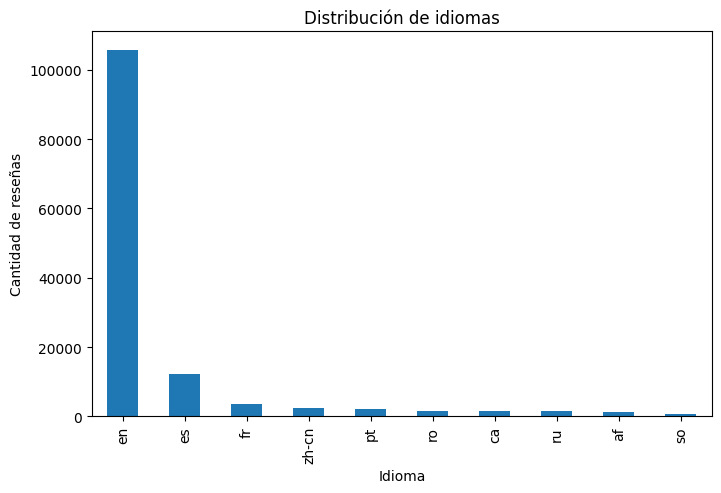

In [14]:
df["language"].value_counts().head(10).plot(kind="bar", figsize=(8,5))

plt.title("Distribución de idiomas")
plt.xlabel("Idioma")
plt.ylabel("Cantidad de reseñas")

plt.show()

# Filtrar reseñas en inglés

In [15]:
df = df[df["language"] == "en"].copy()

# Crear variable sentimiento

In [16]:
def mapear_sentimiento(label):
    if label >= 4:
        return "positive"
    elif label == 3:
        return "neutral"
    else:
        return "negative"

In [17]:
df["sentiment"] = df["Label"].progress_apply(mapear_sentimiento)

  0%|          | 0/105777 [00:00<?, ?it/s]

# Preprocesamiento con NLP

In [18]:
!pip install spacy
!python -m spacy download en_core_web_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 75.1 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [19]:
import spacy
nlp = spacy.load("en_core_web_sm")

In [20]:
def preprocesar(text):
    doc = nlp(str(text).lower())
    tokens = [
        token.lemma_
        for token in doc
        if not token.is_stop
        and not token.is_punct
        and token.is_alpha
    ]
    return " ".join(tokens)

In [21]:
df["clean_review"] = df["Review"].progress_apply(preprocesar)

  0%|          | 0/105777 [00:00<?, ?it/s]

# Dataset luego del preprocesamiento

In [22]:
df.head()

,CourseId,Review,Label,language,sentiment,clean_review
3,2-speed-it,"Great course - I recommend it for all, especia...",5,en,positive,great course recommend especially business man...
4,2-speed-it,One of the most useful course on IT Management!,5,en,positive,useful course management
5,2-speed-it,I was disappointed because the name is mislead...,3,en,neutral,disappoint misleading course provide good intr...
6,2-speed-it,Super content. I'll definitely re-do the course,5,en,positive,super content definitely course
8,2-speed-it,One of the excellent courses at Coursera for i...,5,en,positive,excellent course coursera information technolo...


In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 105777 entries, 3 to 140319
Data columns (total 6 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   CourseId      105777 non-null  object
 1   Review        105777 non-null  object
 2   Label         105777 non-null  int64 
 3   language      105777 non-null  object
 4   sentiment     105777 non-null  object
 5   clean_review  105777 non-null  object
dtypes: int64(1), object(5)
memory usage: 5.6+ MB


In [24]:
df.isnull().sum()

,0
CourseId,0
Review,0
Label,0
language,0
sentiment,0
clean_review,0


# Undersampling

**Distribución de sentimientos**

<Axes: title={'center': 'Distribución de Sentimientos'}, xlabel='sentiment'>

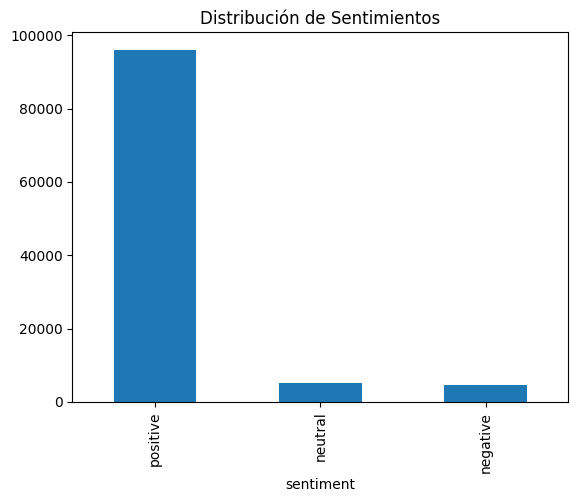

In [25]:
df["sentiment"].value_counts().plot(kind="bar", title="Distribución de Sentimientos")

In [26]:
df["sentiment"].value_counts()

,count
sentiment,
positive,96000
neutral,5070
negative,4707


In [27]:
df_positive = df[df["sentiment"] == "positive"]
df_neutral = df[df["sentiment"] == "neutral"]
df_negative = df[df["sentiment"] == "negative"]

min_size = min(
    len(df_positive),
    len(df_neutral),
    len(df_negative)
)

df_positive_under = df_positive.sample(min_size, random_state=42)
df_neutral_under = df_neutral.sample(min_size, random_state=42)
df_negative_under = df_negative.sample(min_size, random_state=42)

df_balanced = pd.concat([
    df_positive_under,
    df_neutral_under,
    df_negative_under
])

df_balanced = df_balanced.sample(frac=1, random_state=42)

df_balanced["sentiment"].value_counts()

,count
sentiment,
positive,4707
neutral,4707
negative,4707


**Distribución de sentimientos luego del undersampling**

<Axes: title={'center': 'Distribución balanceada de sentimientos'}, xlabel='sentiment'>

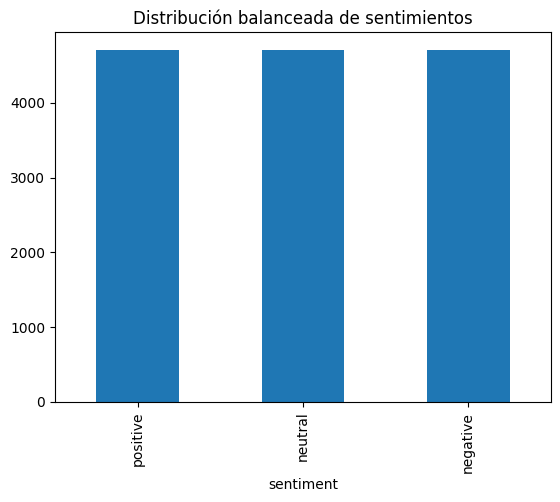

In [28]:
df_balanced["sentiment"].value_counts().plot(
    kind="bar",
    title="Distribución balanceada de sentimientos"
)

# Visualización

<Axes: title={'center': 'Distribución de Ratings'}, xlabel='Label'>

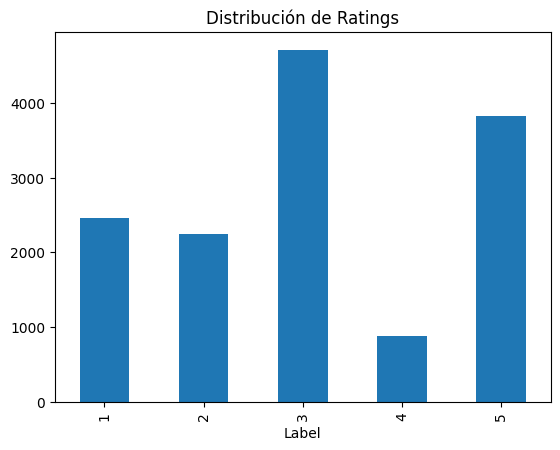

In [29]:
df_balanced["Label"].value_counts().sort_index().plot(kind="bar", title="Distribución de Ratings")

**Top cursos con más reseñas**

<Axes: title={'center': 'Cursos con más reseñas'}, xlabel='CourseId'>

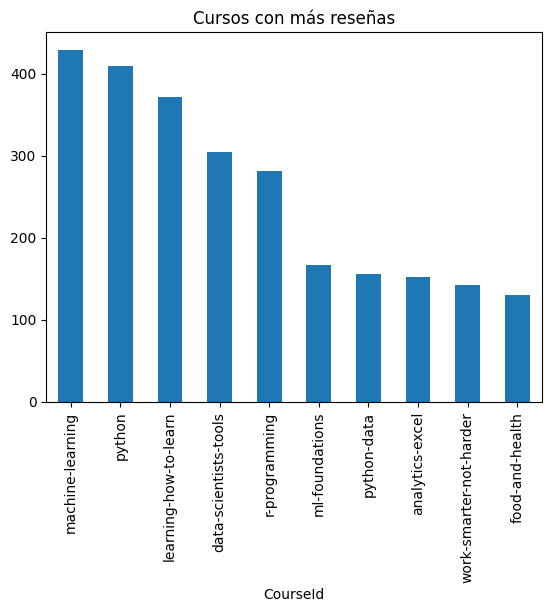

In [30]:
df_balanced["CourseId"].value_counts().head(10).plot(kind="bar", title="Cursos con más reseñas")

**Nube de palabras**

In [31]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

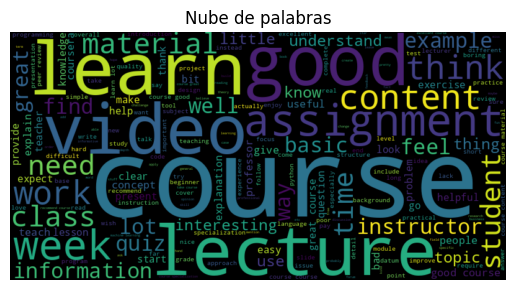

In [32]:
text = " ".join(df_balanced["clean_review"].dropna())

wc = WordCloud(width=800, height=400).generate(text)

plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.title("Nube de palabras")
plt.show()

# Guardar dataset final

In [33]:
df_balanced.to_csv("clean_coursera_reviews.csv", index=False)
print("Dataset listo:", df_balanced.shape)

Dataset listo: (14121, 6)
